# INDEX
### **1. Data loading**
### **2. Exploratory data analysis (EDA)**
2.1. General overview

2.2. Demographic analysis

2.3. Arrhythmia /Diagnostic analysis

2.4. 12 lead_ECG example


# 1. Data loading

In [1]:
# Install dependencies
!pip install wfdb

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/ptbxl.zip"
extract_path = "/content/ptbxl"

# Only unzip if not already extracted in this session
if not os.path.exists(extract_path):
    print("Copying zip to local storage...")
    !cp "{zip_path}" /content/

    print("Unzipping...")
    with zipfile.ZipFile("/content/ptbxl.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/")

    print("Done.")
else:
    print("Dataset already available in local session.")

Copying zip to local storage...
Unzipping...
Done.


In [4]:
path = "/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"

In [5]:
import pandas as pd
import numpy as np
import wfdb
import ast
import os
import matplotlib.pyplot as plt

def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path + f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path + f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

sampling_rate = 100

# Load and convert annotation data
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train, validation, and test according to PTB-XL folds
train_folds = list(range(1, 9))   # 1–8
val_fold = 9                      # 9
test_fold = 10                    # 10

# Train
X_train = X[np.where(Y.strat_fold.isin(train_folds))]
y_train = Y[Y.strat_fold.isin(train_folds)].diagnostic_superclass

# Validation
X_val = X[np.where(Y.strat_fold == val_fold)]
y_val = Y[Y.strat_fold == val_fold].diagnostic_superclass

# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

print("X_train shape:", X_train.shape)
print("y_train sample:", y_train.head())

print("X_val shape:", X_val.shape)
print("y_val sample:", y_val.head())

print("X_test shape:", X_test.shape)
print("y_test sample:", y_test.head())


X_train shape: (17418, 1000, 12)
y_train sample: ecg_id
1    [NORM]
2    [NORM]
3    [NORM]
4    [NORM]
5    [NORM]
Name: diagnostic_superclass, dtype: object
X_val shape: (2183, 1000, 12)
y_val sample: ecg_id
8       [MI]
10    [NORM]
17        []
18        []
20        []
Name: diagnostic_superclass, dtype: object
X_test shape: (2198, 1000, 12)
y_test sample: ecg_id
9     [NORM]
38    [NORM]
40    [NORM]
57    [NORM]
59    [NORM]
Name: diagnostic_superclass, dtype: object


In [6]:
folder_path = path + "records100/00000"

# List all .hea files (each one corresponds to one ECG)
records = [f.replace(".hea", "") for f in os.listdir(folder_path) if f.endswith(".hea")]

print("Found records:", records[:10])

Found records: ['00566_lr', '00850_lr', '00871_lr', '00093_lr', '00653_lr', '00384_lr', '00160_lr', '00147_lr', '00090_lr', '00861_lr']


# 2. Exploratory Data Analysis (EDA)

### 2.1. General overview

In [7]:
# Load metadata
path = "/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"
df = pd.read_csv(path + "ptbxl_database.csv", index_col="ecg_id")

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nFirst 5 rows:")
display(df.head())


Shape of dataset: (21799, 27)

Columns:
Index(['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site',
       'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='str')

Data types:
patient_id                      float64
age                             float64
sex                               int64
height                          float64
weight                          float64
nurse                           float64
site                            float64
device                              str
recording_date                      str
report                              str
scp_codes                           str
heart_axis                          s

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


### 2.2. Descriptive analysis

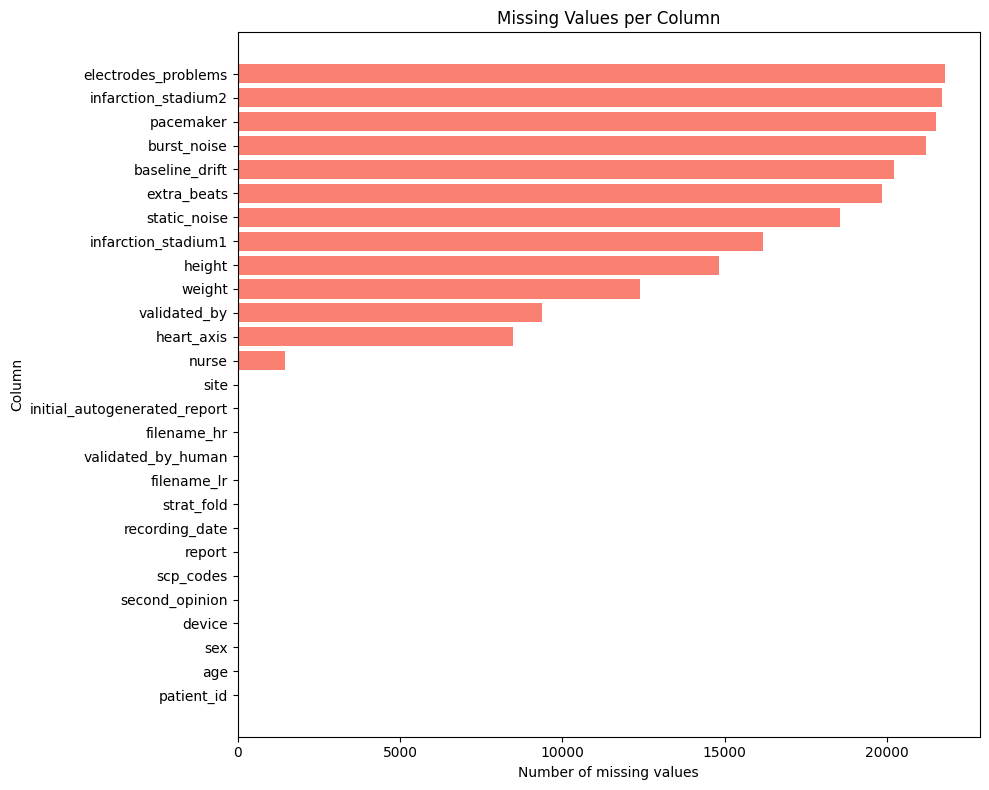

In [8]:
import matplotlib.pyplot as plt

# Compute missing values
missing_counts = df.isnull().sum().sort_values(ascending=True)

plt.figure(figsize=(10,8))
plt.barh(missing_counts.index, missing_counts.values, color="salmon")
plt.title("Missing Values per Column")
plt.xlabel("Number of missing values")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [9]:
from scipy import stats

def describe_column(x):
    # Compute descriptive statistics for a numeric pandas series
    x_no_nan = x.dropna()

    # Mode: scipy returns an array; take the first value
    if len(x_no_nan) > 0:
        mode_val = stats.mode(x_no_nan, keepdims=True).mode[0]
    else:
        mode_val = np.nan

    # Outliers using z-score > 3
    if len(x_no_nan) > 0:
        z = np.abs(stats.zscore(x_no_nan))
        n_outliers = np.sum(z > 3)
    else:
        n_outliers = 0

    return pd.Series({
        "mode": mode_val,
        "mean": x.mean(),
        "median": x.median(),
        "min": x.min(),
        "max": x.max(),
        "std": x.std(),
        "n_outlier": n_outliers
    })

cols_to_describe = ["age", "height", "weight", "nurse", "site"]
T_des = df[cols_to_describe].apply(describe_column)

T_des


,age,height,weight,nurse,site
mode,67.000000,160.000000,70.000000,0.000000,0.000000
mean,62.769301,166.702323,70.995223,2.291745,1.544945
median,62.000000,166.000000,70.000000,1.000000,1.000000
min,2.000000,6.000000,5.000000,0.000000,0.000000
max,300.000000,209.000000,250.000000,11.000000,50.000000
std,32.308813,10.867321,15.878803,3.254033,4.172883
n_outlier,293.000000,22.000000,82.000000,0.000000,423.000000


The median of age is 62, of height 166cm and of wight 70kg, which are understandable. The outliers of height and wight are a few but as seen in the maximum values, they can be real. And the outliers for age are explained in the next section.

Here it can be confirmed that there are 12 unique nurses and 51 sites, where the outliers of site do not make any sense.

### 2.3. Demographic analysis

Sex distribution:
sex
0    11354
1    10445
Name: count, dtype: int64

Percentages:
sex
0    52.084958
1    47.915042
Name: proportion, dtype: float64
sex_label
Male      11354
Female    10445
Name: count, dtype: int64


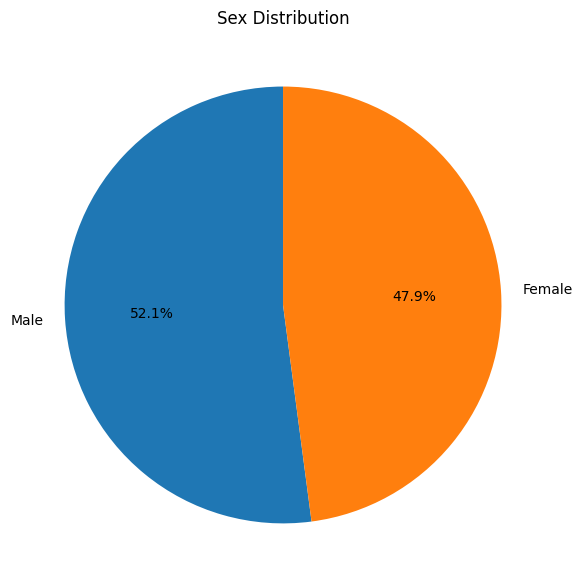

In [10]:
import matplotlib.pyplot as plt

# Count values
sex_counts = df["sex"].value_counts()
print("Sex distribution:")
print(sex_counts)

print("\nPercentages:")
print(df["sex"].value_counts(normalize=True) * 100)

# Map labels
df["sex_label"] = df["sex"].map({0: "Male", 1: "Female"})
print(df["sex_label"].value_counts())

# Donut chart
labels = df["sex_label"].value_counts().index
sizes = df["sex_label"].value_counts().values

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)

plt.title("Sex Distribution")
plt.tight_layout()
plt.show()


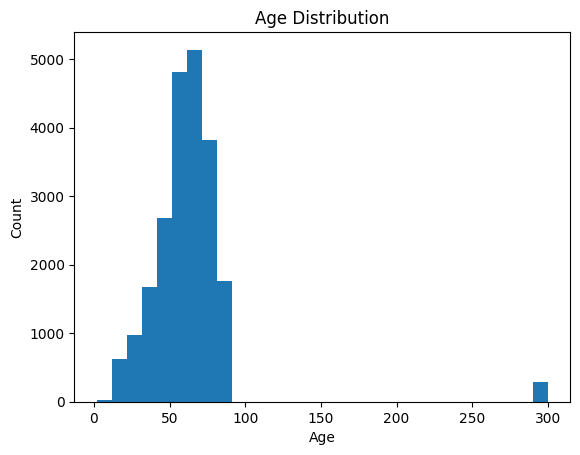

In [11]:
import matplotlib.pyplot as plt

plt.hist(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


For patients with ECGs taken at an age of 90 or older, age is set to 300 years to comply with Health Insurance Portability and Accountability Act (HIPAA) standards.

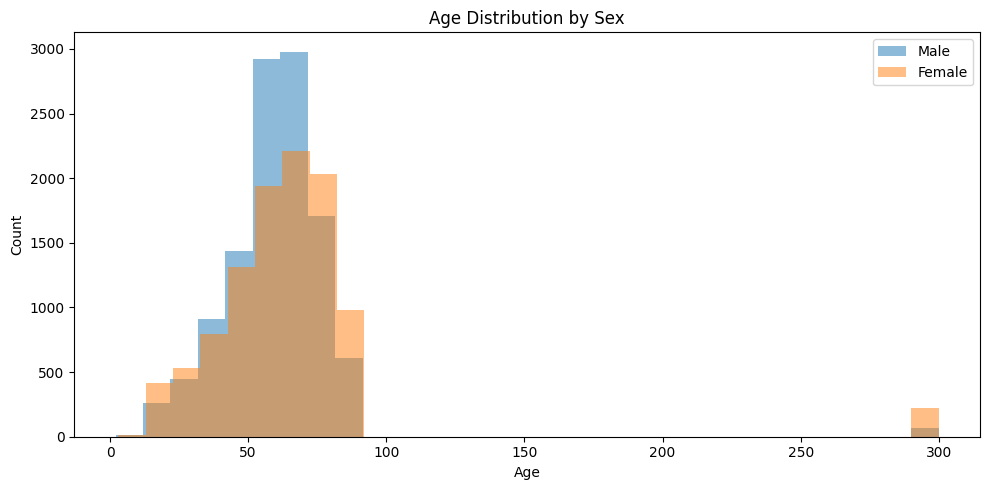

In [12]:
# Ensure sex column exists and is clean
# PTB-XL uses: 0 = male, 1 = female
df["sex"] = df["sex"].map({0: "Male", 1: "Female"})

# Histogram by sex

plt.figure(figsize=(10,5))
for sex in ["Male", "Female"]:
    subset = df[df["sex"] == sex]["age"].dropna()
    plt.hist(subset, bins=30, alpha=0.5, label=sex)

plt.title("Age Distribution by Sex")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

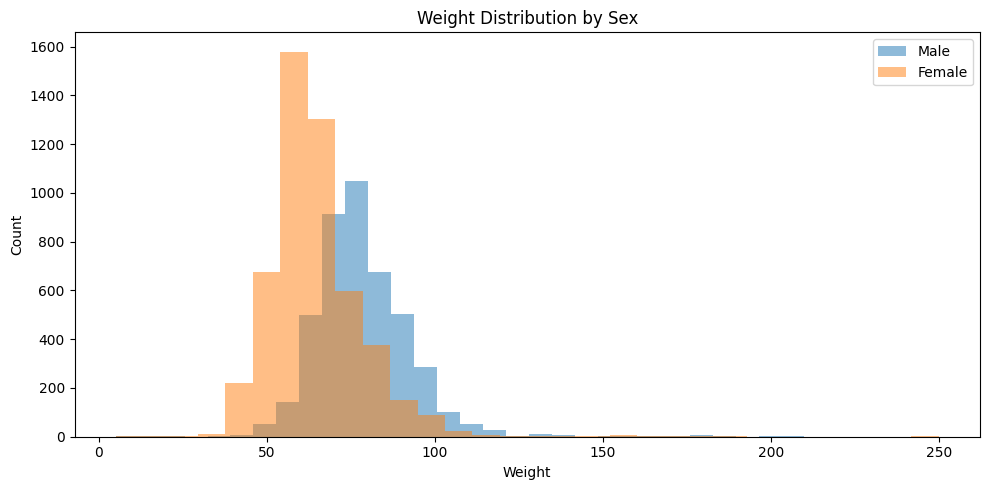

In [13]:
# Histogram by sex for weight
plt.figure(figsize=(10,5))
for sex in ["Male", "Female"]:
    subset = df[df["sex"] == sex]["weight"].dropna()
    plt.hist(subset, bins=30, alpha=0.5, label=sex)

plt.title("Weight Distribution by Sex")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


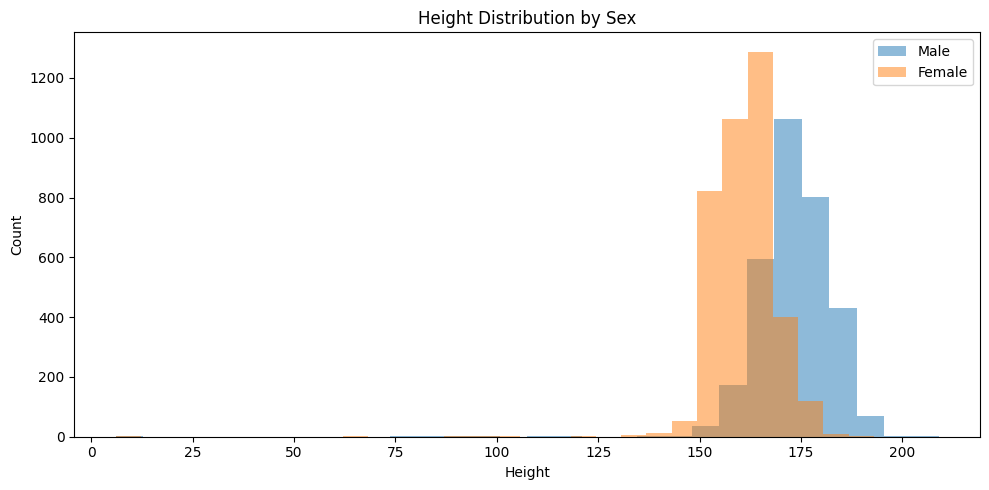

In [14]:
# Histogram by sex for HEIGHT
plt.figure(figsize=(10,5))
for sex in ["Male", "Female"]:
    subset = df[df["sex"] == sex]["height"].dropna()
    plt.hist(subset, bins=30, alpha=0.5, label=sex)

plt.title("Height Distribution by Sex")
plt.xlabel("Height")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


### 2.4. Arrhythmia / Diagnostic analysis



In [15]:
import pandas as pd
import plotly.express as px
import ast

# Load SCP metadata
scp_all = pd.read_csv(path +"scp_statements.csv", index_col=0)

# Fix scp_codes column (convert string → dict)
df["scp_codes"] = df["scp_codes"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Build a long-format table for the hierarchy
rows = []

for idx, row in df.iterrows():
    scp_dict = row["scp_codes"]  # now guaranteed to be a dict

    for code in scp_dict.keys():
        if code in scp_all.index:
            superclass = scp_all.loc[code, "diagnostic_class"]
            subclass = scp_all.loc[code, "diagnostic_subclass"]

            rows.append({
                "superclass": superclass,
                "subclass": subclass,
                "code": code
            })

hier_df = pd.DataFrame(rows)

# Count occurrences
count_df = (
    hier_df.groupby(["superclass", "subclass"])
           .size()
           .reset_index(name="count")
)

# Create the sunburst chart
fig = px.sunburst(
    count_df,
    path=["superclass", "subclass"],
    values="count",
    color="superclass",
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Diagnostic Hierarchy Chart"
)

fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig.show()


In [16]:
# Load full mapping once
scp_all = pd.read_csv(path + "scp_statements.csv", index_col=0)

# Separate views for each use
diag_df   = scp_all[scp_all.diagnostic == 1]
form_df   = scp_all[scp_all.form == 1]
rhythm_df = scp_all[scp_all.rhythm == 1]

# Ensure scp_codes are dicts
if isinstance(df["scp_codes"].iloc[0], str):
    df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

# Helper
def aggregate_labels(y_dic, mapping_df, column_name):
    tmp = []
    for key in y_dic.keys():
        if key in mapping_df.index:
            val = mapping_df.loc[key, column_name]
            if isinstance(val, pd.Series):
                tmp.extend(list(val))
            else:
                tmp.append(val)
    return list(set([str(v) for v in tmp]))


Diagnostic superclass distribution:
NORM : 9514
MI : 5469
STTC : 5235
HYP : 2649
CD : 4898


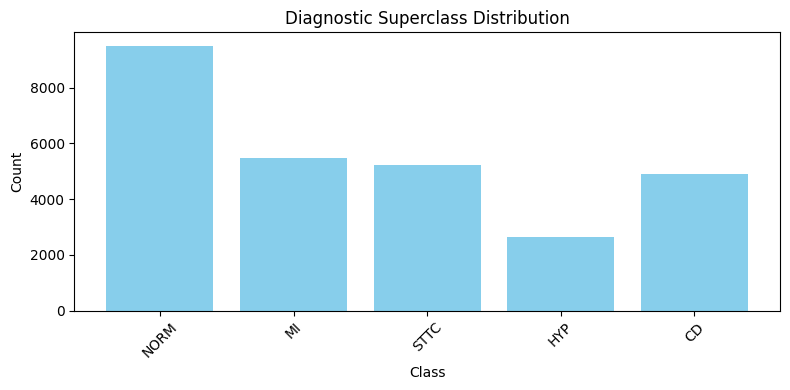

<Figure size 1000x500 with 0 Axes>

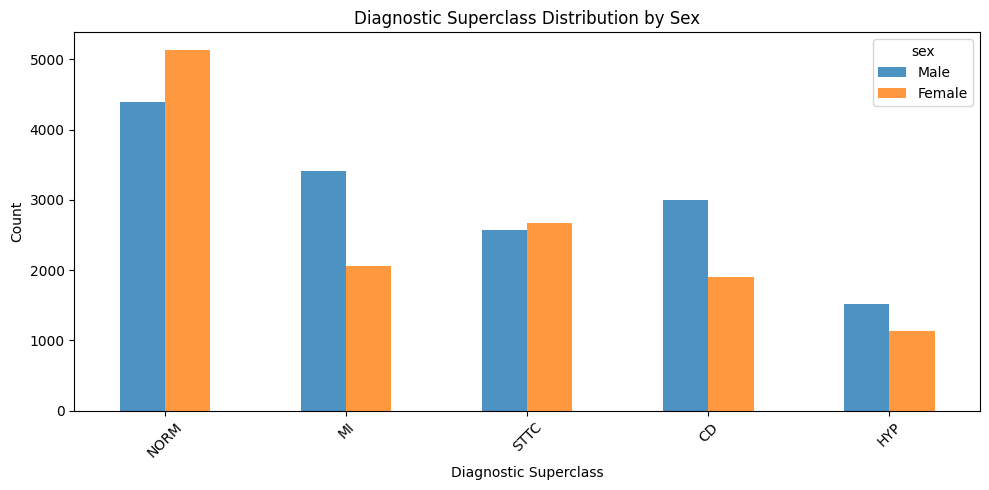

<Figure size 1600x600 with 0 Axes>

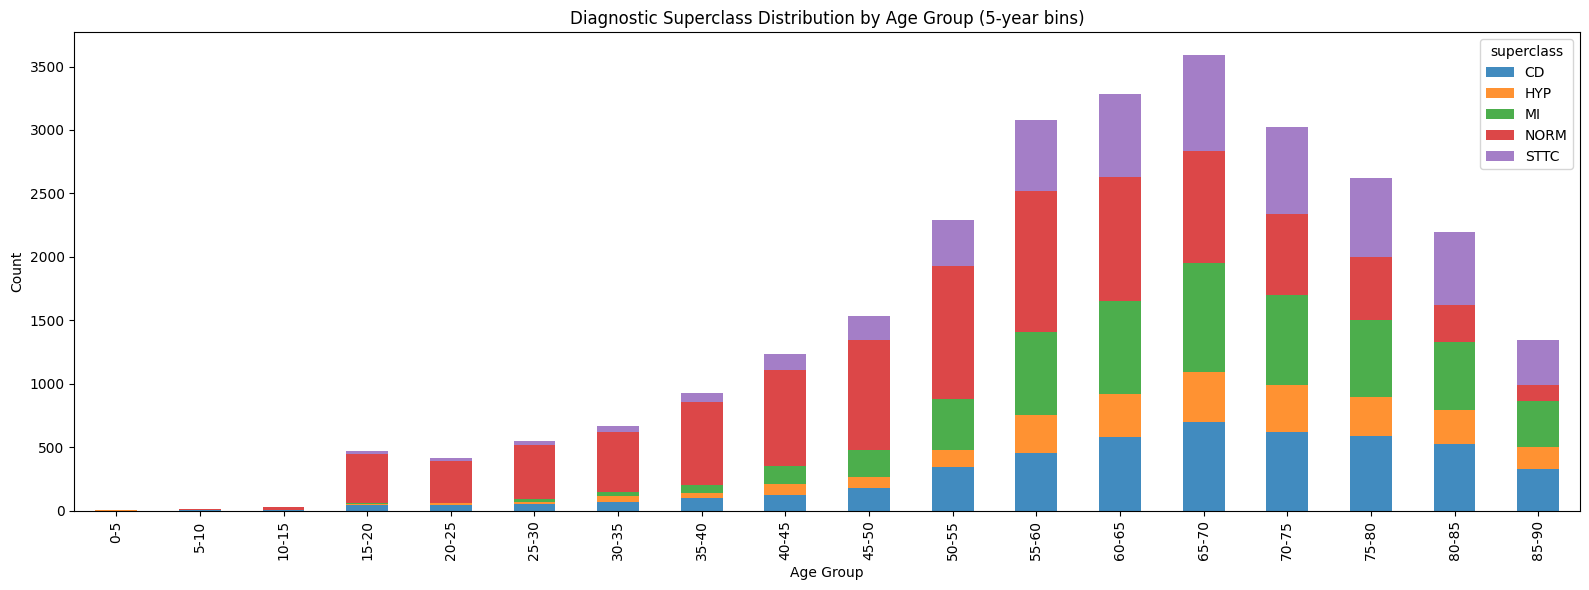

In [17]:
# 1. Diagnostic superclass

from collections import Counter
import matplotlib.pyplot as plt

df["diagnostic_superclass"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, diag_df, "diagnostic_class")
)

all_labels = [label for sublist in df["diagnostic_superclass"] for label in sublist]
label_counts = Counter(all_labels)

print("Diagnostic superclass distribution:")
for k, v in label_counts.items():
    print(k, ":", v)

plt.figure(figsize=(8,4))
plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.xticks(rotation=45)
plt.title("Diagnostic Superclass Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# 1-a Diagnostic superclass distribution by sex

# Expand diagnostic superclass into rows for grouping
rows = []
for idx, row in df.iterrows():
    sex = row["sex"]
    for cls in row["diagnostic_superclass"]:
        rows.append({"sex": sex, "superclass": cls})

sex_df = pd.DataFrame(rows)

# Count per sex per superclass
sex_counts = sex_df.groupby(["superclass", "sex"]).size().unstack(fill_value=0)

sex_counts = sex_counts[["Male", "Female"]]

# Sort by total count (descending)
sex_counts = sex_counts.loc[sex_counts.sum(axis=1).sort_values(ascending=False).index]

# Plot
plt.figure(figsize=(10,5))
sex_counts.plot(kind="bar", figsize=(10,5), alpha=0.8)
plt.title("Diagnostic Superclass Distribution by Sex")
plt.xlabel("Diagnostic Superclass")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 1-b Diagnostic superclass distribution by age groups

# Create age bins (5-year groups)
age_bins = list(range(0, 95, 5))  # 0–5, 5–10, ..., 85–90
age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]

df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)

# Expand rows: one row per (age_group, superclass)
rows = []
for idx, row in df.iterrows():
    age_group = row["age_group"]
    for cls in row["diagnostic_superclass"]:
        rows.append({"age_group": age_group, "superclass": cls})

age_df = pd.DataFrame(rows)

# Count per age group per superclass
age_counts = (
    age_df.groupby(["age_group", "superclass"])
          .size()
          .unstack(fill_value=0)
)

# Sort age groups in natural order
age_counts = age_counts.loc[age_labels]

# Plot
plt.figure(figsize=(16,6))
age_counts.plot(kind="bar", stacked=True, figsize=(16,6), alpha=0.85)
plt.xticks(rotation=90)
plt.title("Diagnostic Superclass Distribution by Age Group (5-year bins)")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In the graph "Diagnostic Superclass Distribution by Age Group" the younger ones barely have diagnosticated arrythmias, so it can be observed that the older the patient the more arrythmias appear and the lesser "Normal" diagnosis emerge.


Diagnostic subclass distribution:
nan : 21194
NORM : 9514
IMI : 3271
STTC : 2239
NST_ : 767
LVH : 2132
LAFB/LPFB : 1797
RVH : 126
RAO/RAE : 99
IRBBB : 1118
IVCD : 787
LMI : 201
AMI : 3078
_AVB : 823
ISCA : 941
SEHYP : 29
ISCI : 397
ISC_ : 1272
CRBBB : 541
CLBBB : 536
LAO/LAE : 426
ILBBB : 77
PMI : 17
WPW : 79


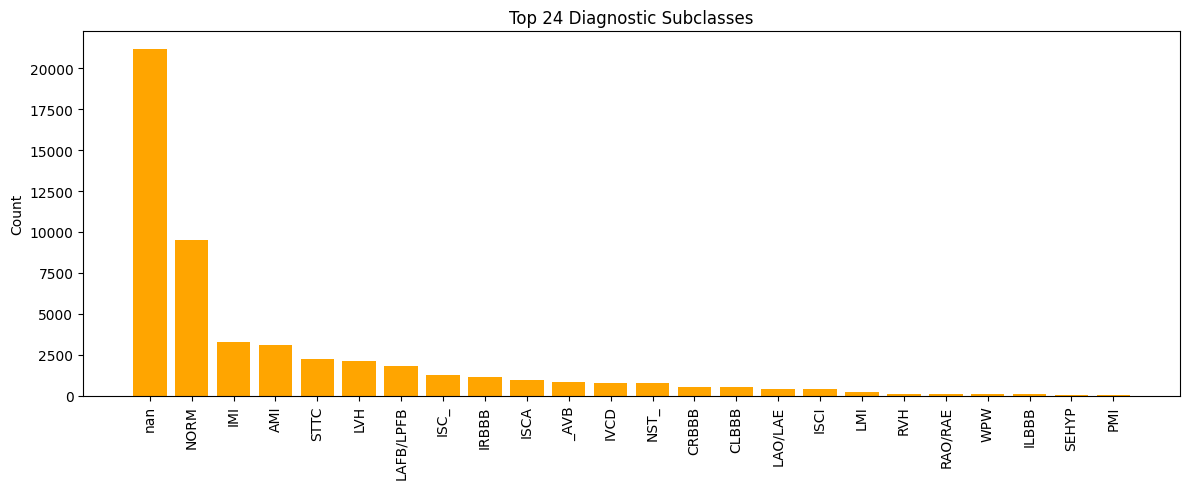

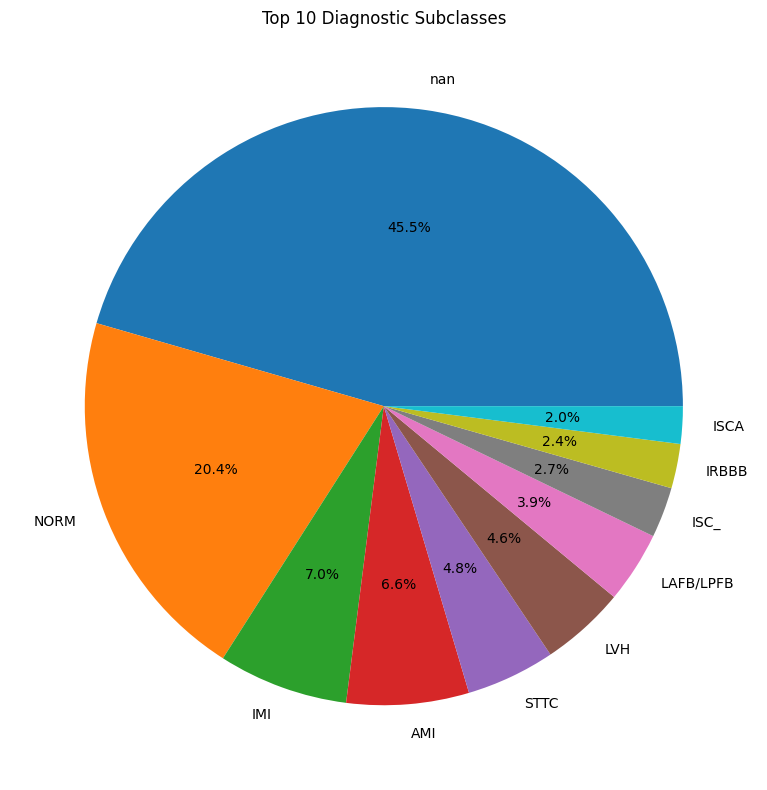

<Figure size 1400x600 with 0 Axes>

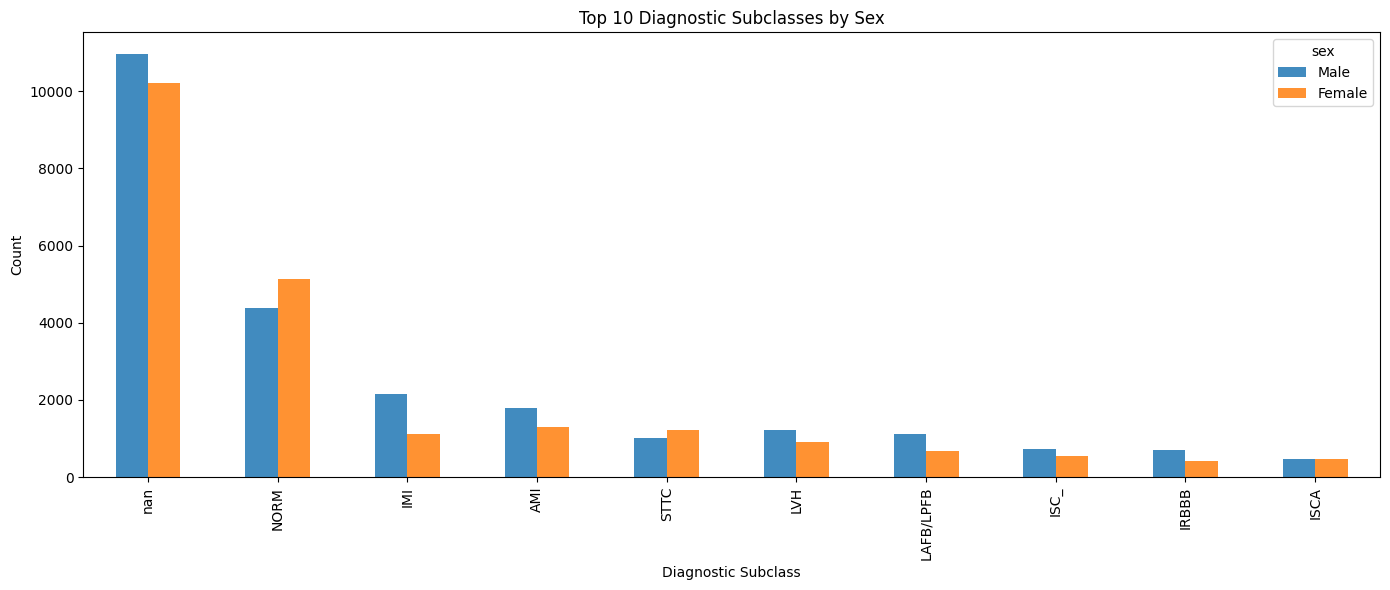

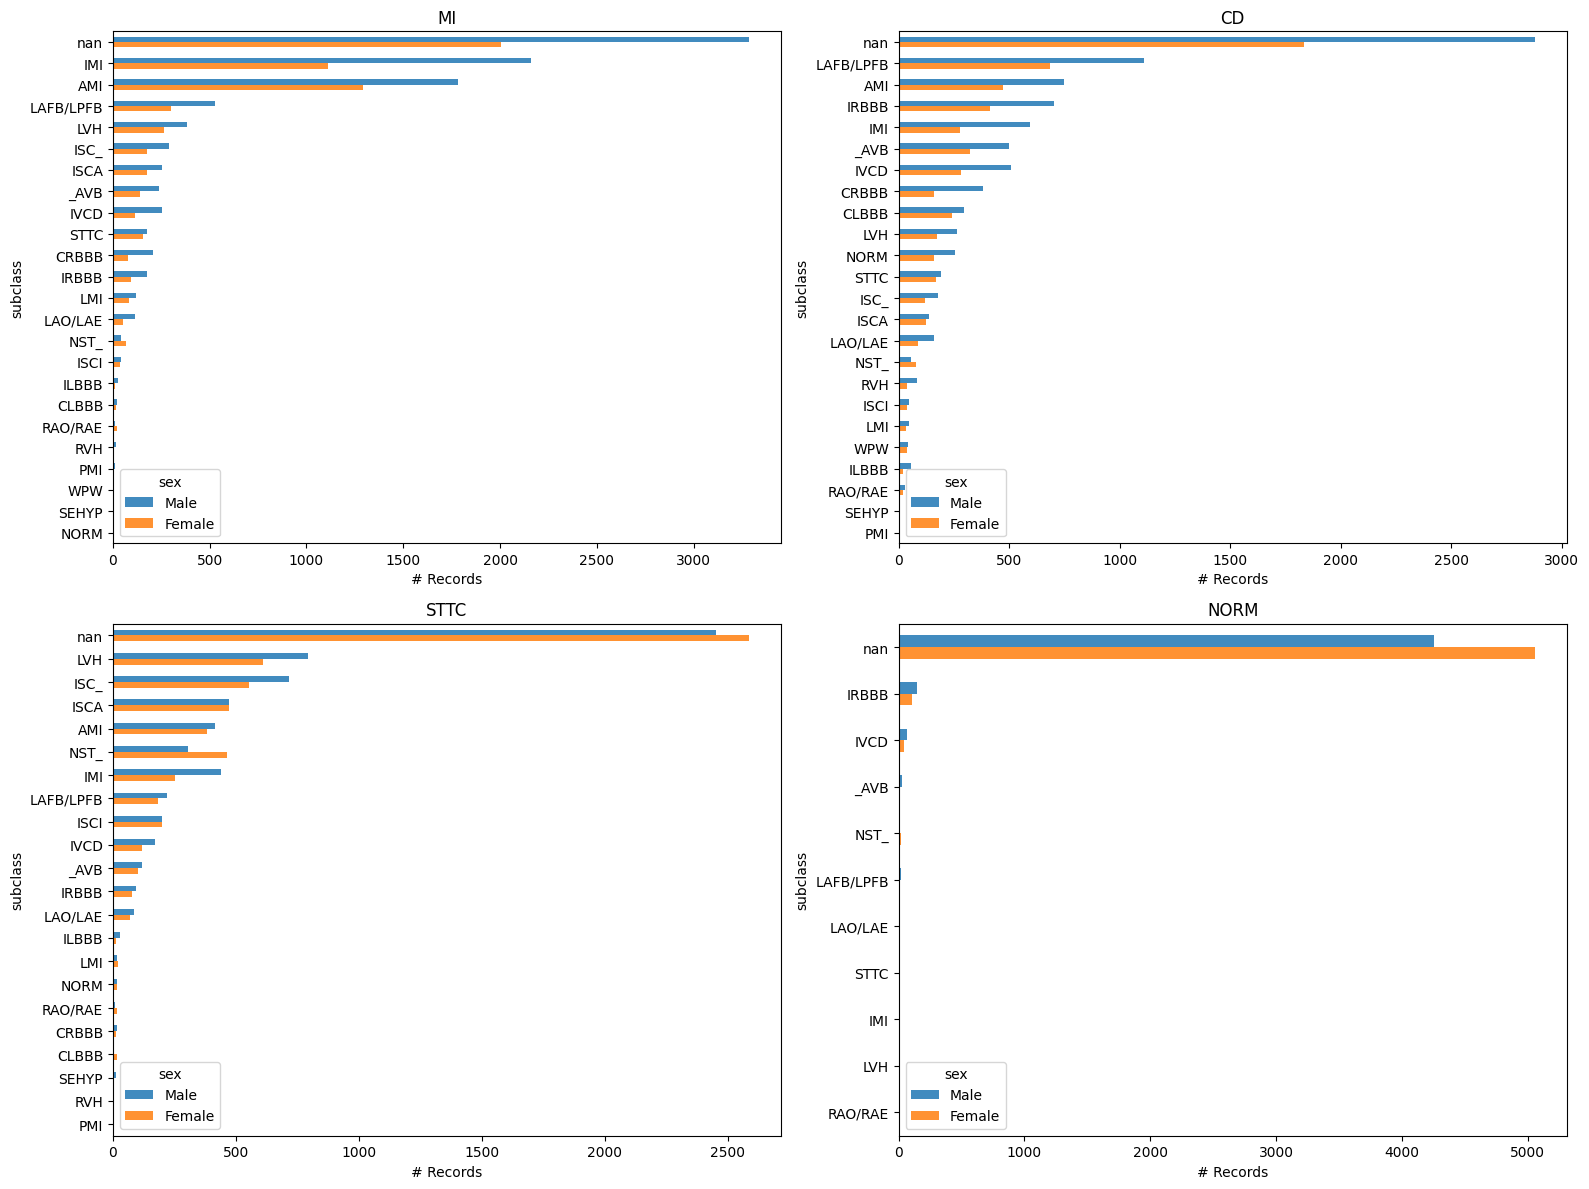

<Figure size 1800x600 with 0 Axes>

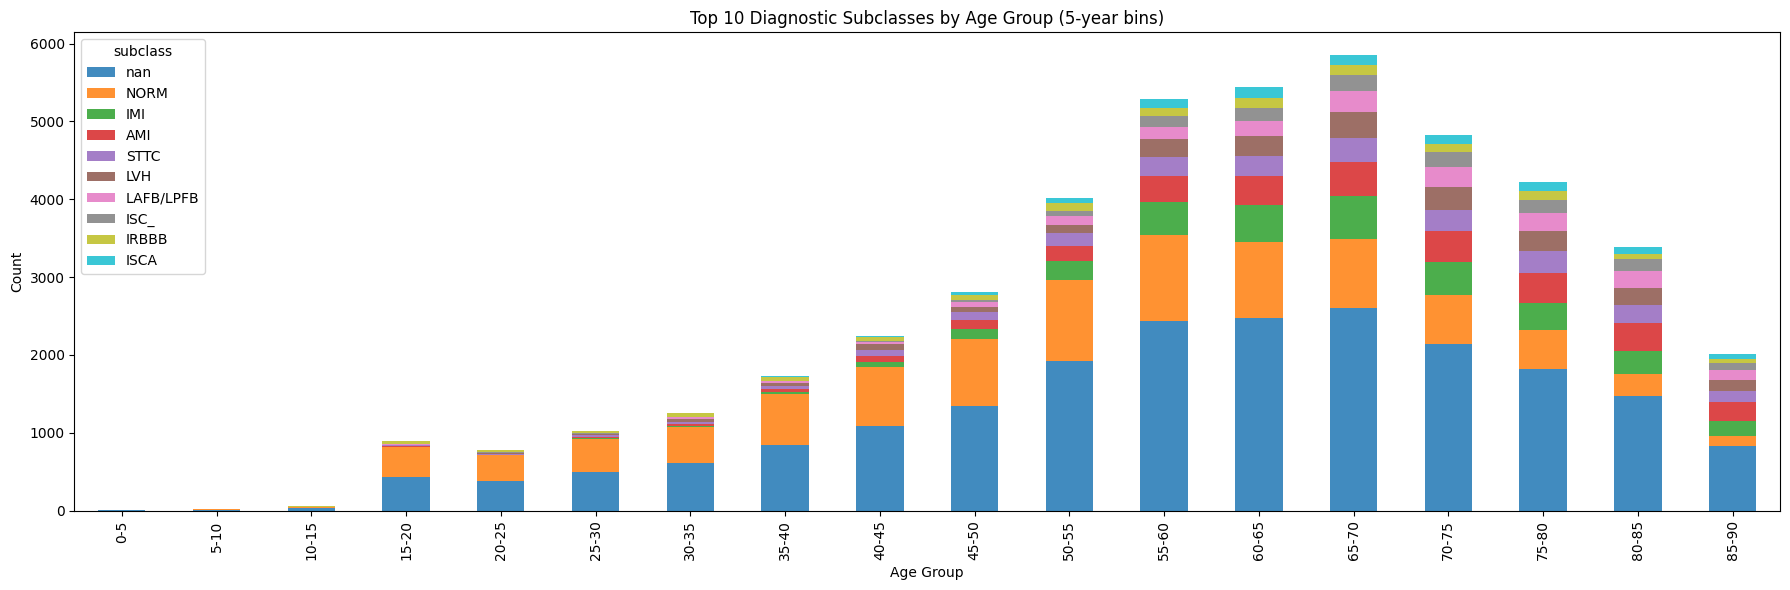

In [18]:
# 2. Diagnostic subclass

df["diagnostic_subclass"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, scp_all, "diagnostic_subclass")
)

all_labels = [label for sublist in df["diagnostic_subclass"] for label in sublist]
label_counts = Counter(all_labels)

print("\nDiagnostic subclass distribution:")
for k, v in label_counts.items():
    print(k, ":", v)

top_n = 24
top_items = dict(label_counts.most_common(top_n))

plt.figure(figsize=(12,5))
plt.bar(top_items.keys(), top_items.values(), color='orange')
plt.xticks(rotation=90)
plt.title(f"Top {top_n} Diagnostic Subclasses")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart of top subclasses
top_n = 10
top_items = dict(label_counts.most_common(top_n))

plt.figure(figsize=(8,8))
plt.pie(top_items.values(), labels=top_items.keys(), autopct="%1.1f%%")
plt.title(f"Top {top_n} Diagnostic Subclasses")
plt.tight_layout()
plt.show()


# 2-a Diagnostic subclass distribution by sex

# Expand subclass into rows for grouping
rows = []
for idx, row in df.iterrows():
    sex = row["sex"]
    for subclass in row["diagnostic_subclass"]:
        rows.append({"sex": sex, "subclass": subclass})

sex_sub_df = pd.DataFrame(rows)

# Count per sex per subclass
sex_sub_counts = sex_sub_df.groupby(["subclass", "sex"]).size().unstack(fill_value=0)

sex_sub_counts = sex_sub_counts[["Male", "Female"]]

# Sort by total count (descending)
sex_sub_counts = sex_sub_counts.loc[
    sex_sub_counts.sum(axis=1).sort_values(ascending=False).index
]

# Keep only the top N (same as above)
sex_sub_counts = sex_sub_counts.head(top_n)

# Plot grouped bar chart
plt.figure(figsize=(14,6))
sex_sub_counts.plot(kind="bar", figsize=(14,6), alpha=0.85)
plt.title(f"Top {top_n} Diagnostic Subclasses by Sex")
plt.xlabel("Diagnostic Subclass")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



# 2-b Diagnostic subclasses grouped by superclass and sex

# Build a long table: one row per (sex, superclass, subclass)
rows = []
for idx, row in df.iterrows():
    sex = row["sex"]
    superclasses = row["diagnostic_superclass"]
    subclasses = row["diagnostic_subclass"]

    for sc in superclasses:
        for sub in subclasses:
            rows.append({"sex": sex, "superclass": sc, "subclass": sub})

sex_sub_df = pd.DataFrame(rows)

# Clean subclass values
sex_sub_df["subclass"] = sex_sub_df["subclass"].fillna("Unknown")
sex_sub_df = sex_sub_df[sex_sub_df["subclass"] != sex_sub_df["superclass"]]

# Count subclasses within each superclass, separated by sex
grouped_sex = (
    sex_sub_df.groupby(["superclass", "subclass", "sex"])
              .size()
              .reset_index(name="count")
)

# Determine superclass order by total count
superclass_order = (
    grouped_sex.groupby("superclass")["count"]
               .sum()
               .sort_values(ascending=False)
               .index
)

# Create one subplot per superclass
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, sc in zip(axes, superclass_order[:4]):  # top 4 superclasses
    sub_data = grouped_sex[grouped_sex["superclass"] == sc]

    # Pivot so subclasses are rows and sex are columns
    pivot = sub_data.pivot(index="subclass", columns="sex", values="count").fillna(0)

    # Force consistent sex column order
    pivot = pivot.rename(columns={0: "Male", 1: "Female", "0": "Male", "1": "Female"})
    pivot = pivot[["Male", "Female"]]

    # Sort by total count
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # Plot horizontal grouped bars
    pivot.plot(kind="barh", ax=ax, alpha=0.85)
    ax.set_title(sc)
    ax.set_xlabel("# Records")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()



# 3-c Diagnostic subclass distribution by age groups

# Create age bins (5-year groups)
age_bins = list(range(0, 95, 5))  # 0–5, 5–10, ..., 85–90
age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]

df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)

# Expand rows: one row per (age_group, subclass)
rows = []
for idx, row in df.iterrows():
    age_group = row["age_group"]
    for subclass in row["diagnostic_subclass"]:
        rows.append({"age_group": age_group, "subclass": subclass})

age_sub_df = pd.DataFrame(rows)

# Count per age group per subclass
age_sub_counts = (
    age_sub_df.groupby(["age_group", "subclass"])
              .size()
              .unstack(fill_value=0)
)

# Keep only the top N subclasses (same top_n as above)
top_subclasses = list(top_items.keys())
age_sub_counts = age_sub_counts[top_subclasses]

# Sort age groups in natural order
age_sub_counts = age_sub_counts.loc[age_labels]

# Plot
plt.figure(figsize=(18,6))
age_sub_counts.plot(kind="bar", stacked=True, figsize=(18,6), alpha=0.85)
plt.xticks(rotation=90)
plt.title(f"Top {top_n} Diagnostic Subclasses by Age Group (5-year bins)")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In the graph "Top 24 Diagnostic Subclasses" the high count for "nan" indicates missing or unassigned subclass labels, which makes "NORM" the most common subclass. As the other subclasses appear with lower frequencies, class imbalance will be present.

In the graphs where diagnostic subclasses are grouped by superclass there is a tendency that shows more cases of males than females.

In the case of "Diagnostic Subclasses by Age Group (5-year bins)", the older the patients the more subclasses diagnosis and less "NORM" appear.




Form distribution:
low QRS voltages in the frontal and horizontal leads : 182
abnormal QRS : 3327
non-diagnostic T abnormalities : 1825
non-specific ST changes : 767
digitalis-effect : 181
long QT-interval : 117
ventricular premature complex : 1143
T-wave abnormality : 35
high QRS voltage : 62
atrial premature complex : 398
low amplitude T-waves : 438
non-specific ST depression : 1009
non-specific T-wave changes : 423
Q waves present : 548
inverted T-waves : 294
prolonged PR interval : 340
voltage criteria (QRS) for left ventricular hypertrophy : 875
premature complex(es) : 10
non-specific ST elevation : 28


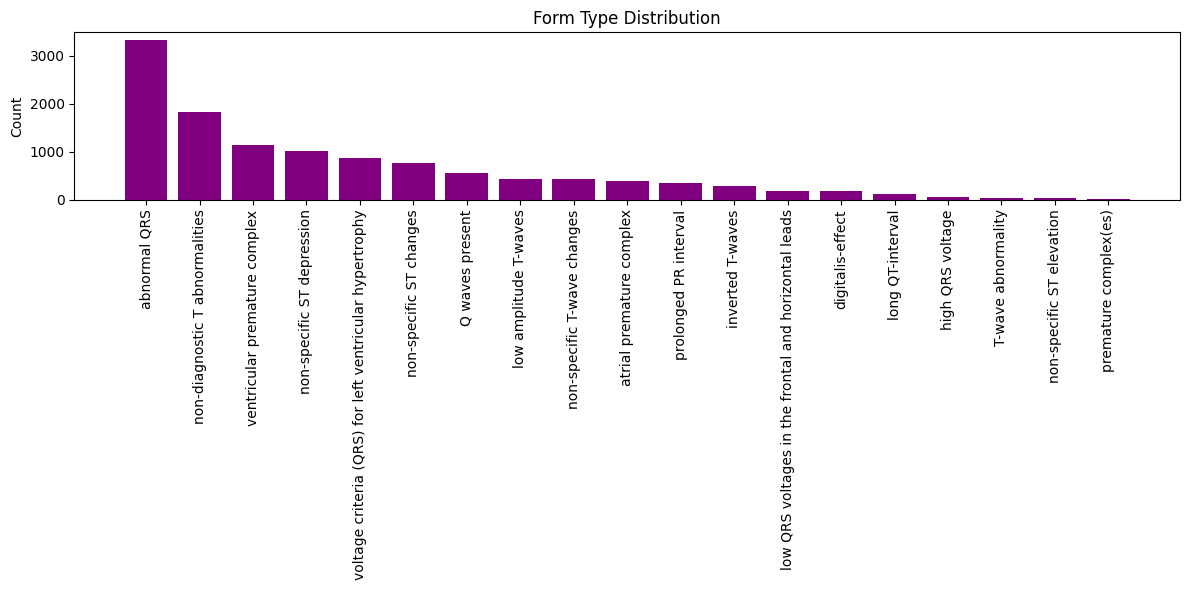

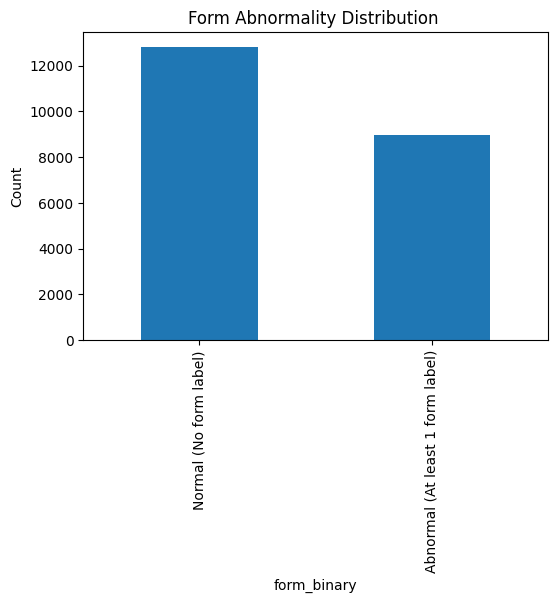


Form abnormality percentage:
form_binary
0    58.814625
1    41.185375
Name: proportion, dtype: float64


<Figure size 1400x600 with 0 Axes>

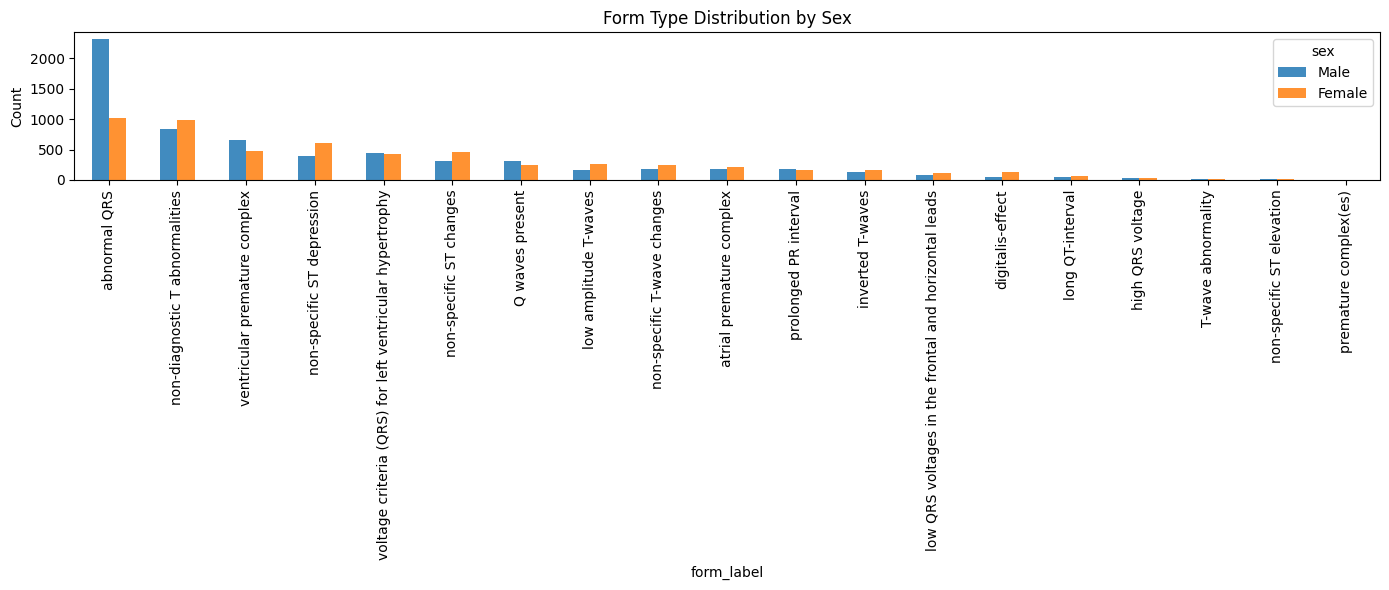

<Figure size 600x400 with 0 Axes>

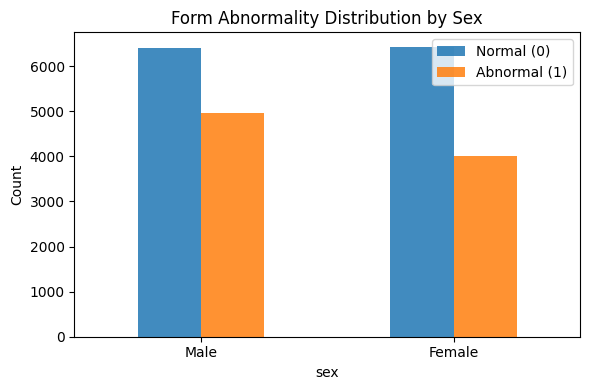


Form abnormality percentage by sex:
form_binary          0          1
sex                              
Male         56.297340  43.702660
Female       61.550981  38.449019


In [19]:
# 3. Form

# Extract form labels
df["form"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, form_df, "description")
)

# Flatten for counting
all_forms = [label for sublist in df["form"] for label in sublist]
form_counts = Counter(all_forms)

print("\nForm distribution:")
for k, v in form_counts.items():
    print(k, ":", v)

# Categorical form distribution

plt.figure(figsize=(12,6))
sorted_form_counts = dict(sorted(form_counts.items(), key=lambda x: x[1], reverse=True))

plt.bar(sorted_form_counts.keys(), sorted_form_counts.values(), color="purple")
plt.xticks(rotation=90)
plt.title("Form Type Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3-a Binary form abnormality

df["form_binary"] = df["form"].apply(lambda x: 1 if len(x) > 0 else 0)

plt.figure(figsize=(6,4))
df["form_binary"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Normal (No form label)", "Abnormal (At least 1 form label)"])
plt.title("Form Abnormality Distribution ")
plt.ylabel("Count")
plt.show()

print("\nForm abnormality percentage:")
print(df["form_binary"].value_counts(normalize=True) * 100)



# 3-b Form type distribution by sex

# Build long table: one row per (sex, form_label)
rows = []
for idx, row in df.iterrows():
    sex = row["sex"]
    for form_label in row["form"]:
        rows.append({"sex": sex, "form_label": form_label})

form_sex_df = pd.DataFrame(rows)

# Count per sex per form label
form_sex_counts = (
    form_sex_df.groupby(["form_label", "sex"])
               .size()
               .unstack(fill_value=0)
)

form_sex_counts = form_sex_counts[["Male", "Female"]]

# Sort by total count
form_sex_counts = form_sex_counts.loc[
    form_sex_counts.sum(axis=1).sort_values(ascending=False).index
]

# Plot
plt.figure(figsize=(14,6))
form_sex_counts.plot(kind="bar", figsize=(14,6), alpha=0.85)
plt.xticks(rotation=90)
plt.title("Form Type Distribution by Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# 3-c Form abnormality separated by sex

# Create a table with counts of normal/abnormal form per sex
form_sex = df.groupby("sex")["form_binary"].value_counts().unstack(fill_value=0)

# Ensure sex labels are correct (in case they are still 0/1)
form_sex = form_sex.rename(index={0: "Male", 1: "Female", "0": "Male", "1": "Female"})

# Force consistent ordering: Male first, Female second
form_sex = form_sex.loc[["Male", "Female"]]

# Plot the bar chart
plt.figure(figsize=(6,4))
form_sex.plot(kind="bar", figsize=(6,4), alpha=0.85)
plt.xticks(rotation=0)
plt.title("Form Abnormality Distribution by Sex")
plt.ylabel("Count")
plt.legend(["Normal (0)", "Abnormal (1)"])
plt.tight_layout()
plt.show()

# Print percentages
print("\nForm abnormality percentage by sex:")
print((form_sex.div(form_sex.sum(axis=1), axis=0) * 100))




There are quite more patients without a label of "form" as it can be seen in the chart "Form Abnormality Distribution".

In the next plot "Form Type Distribution by Sex", the form label "abnormal QRS" is the most frequent one and the males quantity doubles the females one.


Rhythm distribution:
sinus rhythm : 16748
sinus bradycardia : 637
sinus arrhythmia : 772
atrial fibrillation : 1514
atrial flutter : 73
sinus tachycardia : 826
normal functioning artificial pacemaker : 294
supraventricular tachycardia : 27
bigeminal pattern (unknown origin, SV or Ventricular) : 82
trigeminal pattern (unknown origin, SV or Ventricular) : 20
paroxysmal supraventricular tachycardia : 24
supraventricular arrhythmia : 157

Rhythm code presence percentage:
rhythm_binary
1    96.472315
0     3.527685
Name: proportion, dtype: float64


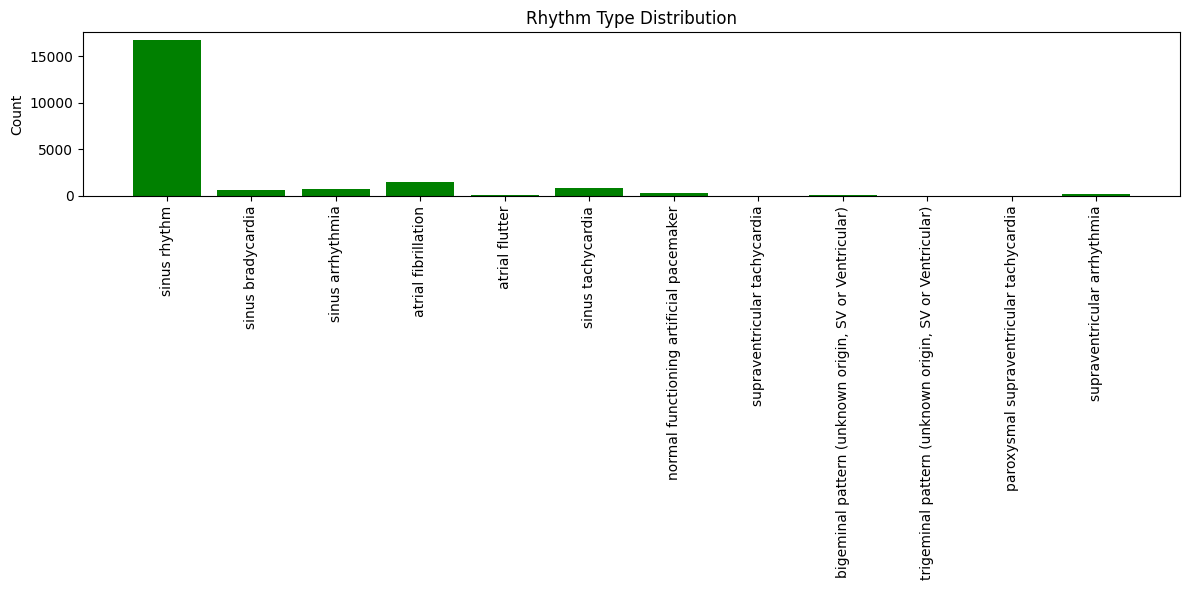

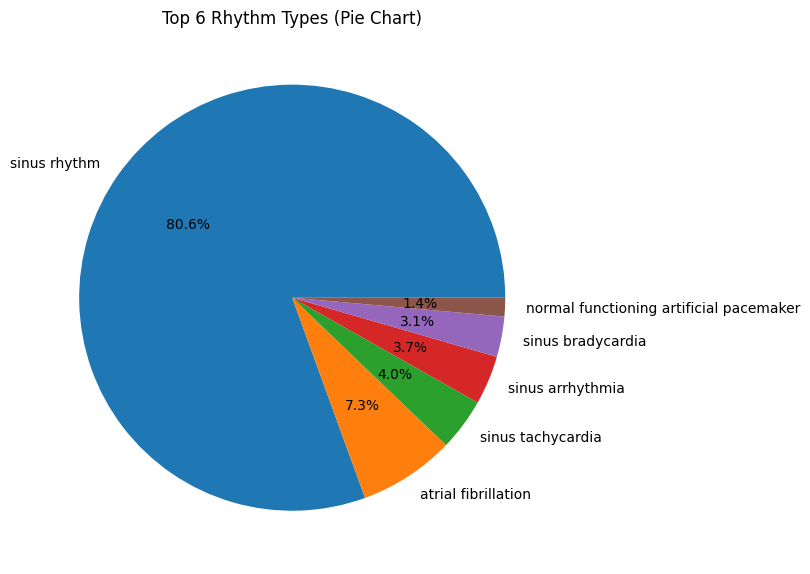

<Figure size 1400x600 with 0 Axes>

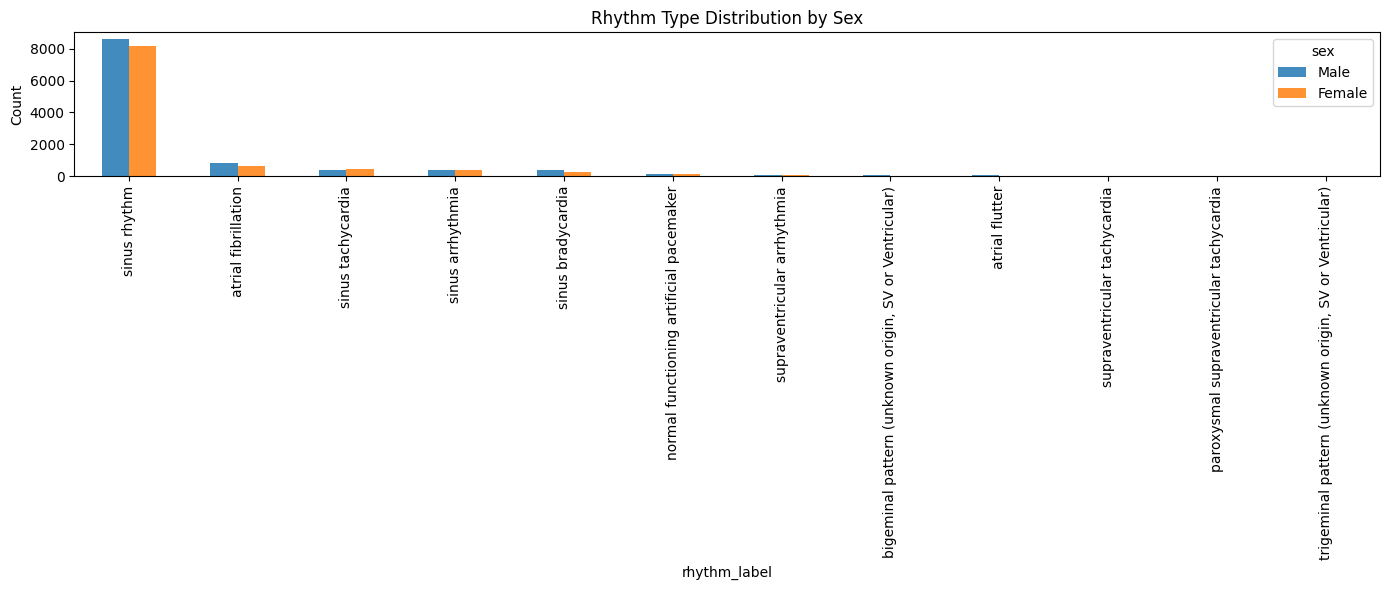

In [20]:
# 4. Rhythm

df["rhythm"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, rhythm_df, "description")
)

all_rhythm = [label for sublist in df["rhythm"] for label in sublist]
rhythm_counts = Counter(all_rhythm)

print("\nRhythm distribution:")
for k, v in rhythm_counts.items():
    print(k, ":", v)

# Binary: presence of any rhythm label
df["rhythm_binary"] = df["rhythm"].apply(lambda x: 1 if len(x) > 0 else 0)

print("\nRhythm code presence percentage:")
print(df["rhythm_binary"].value_counts(normalize=True) * 100)

plt.figure(figsize=(12,6))
plt.bar(rhythm_counts.keys(), rhythm_counts.values(), color="green")
plt.xticks(rotation=90)
plt.title("Rhythm Type Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart of top rhythm types
top_n = 6
top_rhythm = dict(rhythm_counts.most_common(top_n))

plt.figure(figsize=(8,8))
plt.pie(top_rhythm.values(), labels=top_rhythm.keys(), autopct="%1.1f%%")
plt.title(f"Top {top_n} Rhythm Types (Pie Chart)")
plt.tight_layout()
plt.show()



# 4-a Rhythm type distribution by sex


# Build long table: one row per (sex, rhythm_label)
rows = []
for idx, row in df.iterrows():
    sex = row["sex"]
    for rhythm_label in row["rhythm"]:
        rows.append({"sex": sex, "rhythm_label": rhythm_label})

rhythm_sex_df = pd.DataFrame(rows)

# Count per sex per rhythm label
rhythm_sex_counts = (
    rhythm_sex_df.groupby(["rhythm_label", "sex"])
                 .size()
                 .unstack(fill_value=0)
)

rhythm_sex_counts = rhythm_sex_counts[["Male", "Female"]]

# Sort by total count
rhythm_sex_counts = rhythm_sex_counts.loc[
    rhythm_sex_counts.sum(axis=1).sort_values(ascending=False).index
]

# Plot
plt.figure(figsize=(14,6))
rhythm_sex_counts.plot(kind="bar", figsize=(14,6), alpha=0.85)
plt.xticks(rotation=90)
plt.title("Rhythm Type Distribution by Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



All these three figure show that most frequent label data for rhythm by far is "sinus rhythm", which results in a clear class imbalance.


SCP-ECG Statement distribution (all shown):
low QRS voltages in the frontal and horizontal leads : 182
sinus rhythm : 16748
normal ECG : 9514
sinus bradycardia : 637
inferior myocardial infarction : 2676
abnormal QRS : 3327
sinus arrhythmia : 772
atrial fibrillation : 1514
atrial flutter : 73
non-diagnostic T abnormalities : 1825
non-specific ST changes : 767
suggests digitalis-effect : 181
left ventricular hypertrophy : 2132
left posterior fascicular block : 177
long QT-interval : 117
left anterior fascicular block : 1623
incomplete right bundle branch block : 1118
right atrial overload/enlargement : 99
right ventricular hypertrophy : 126
non-specific intraventricular conduction disturbance : 787
lateral myocardial infarction : 201
anteroseptal myocardial infarction : 2357
anterior myocardial infarction : 353
in anterolateral leads : 804
first degree AV block : 793
sinus tachycardia : 826
normal functioning artificial pacemaker : 294
septal hypertrophy : 29
in lateral leads : 157
in 

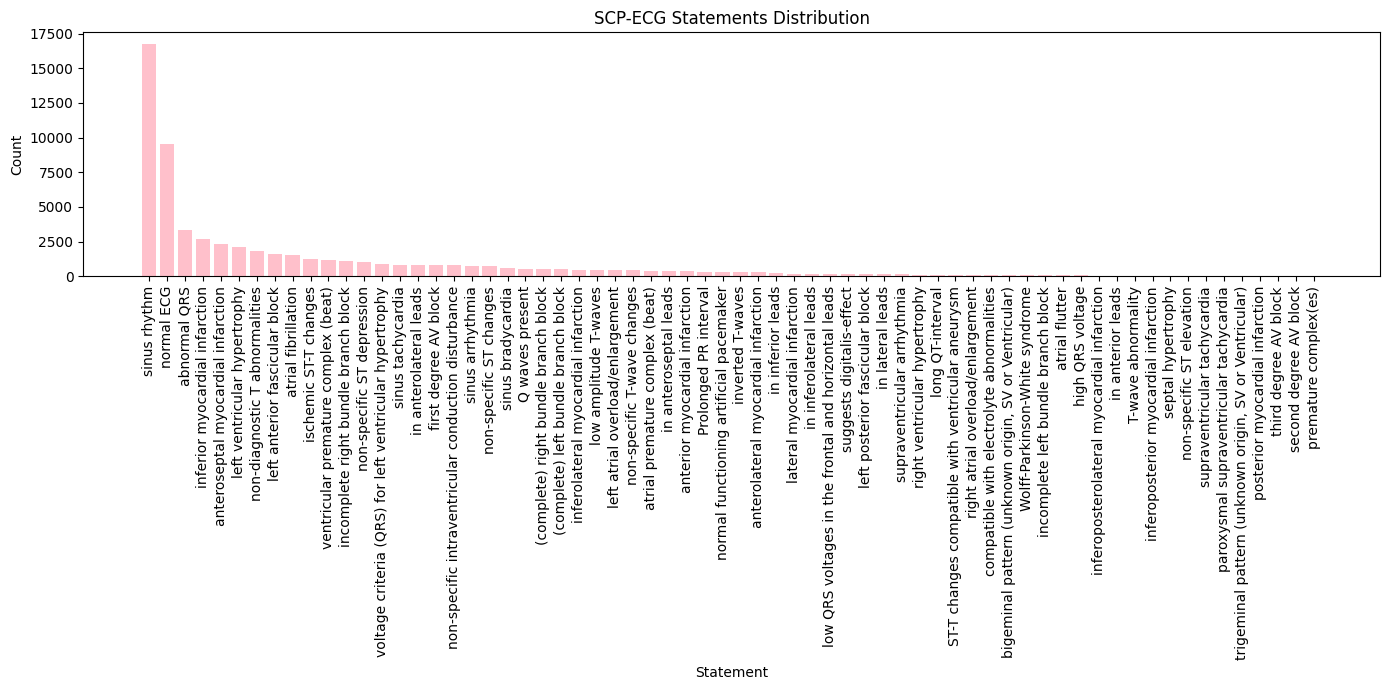

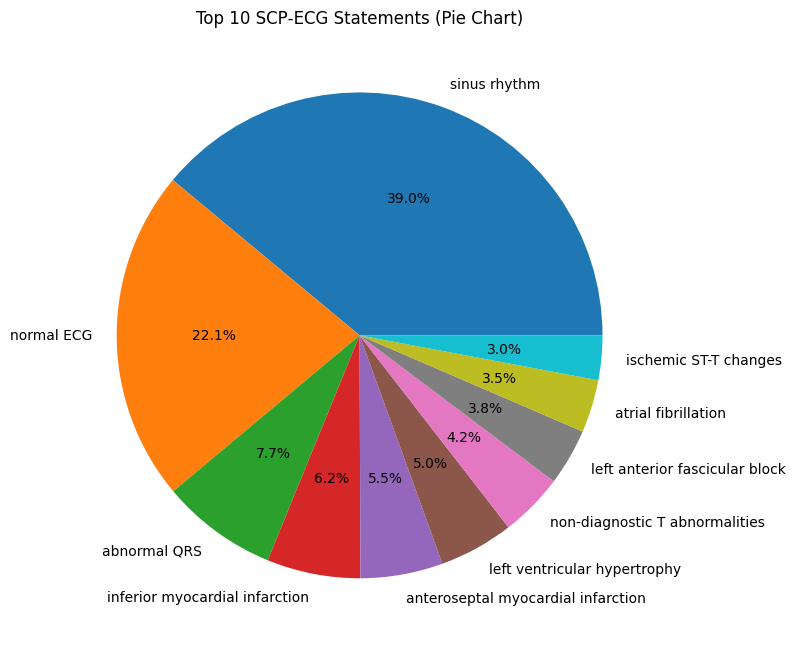

<Figure size 1600x700 with 0 Axes>

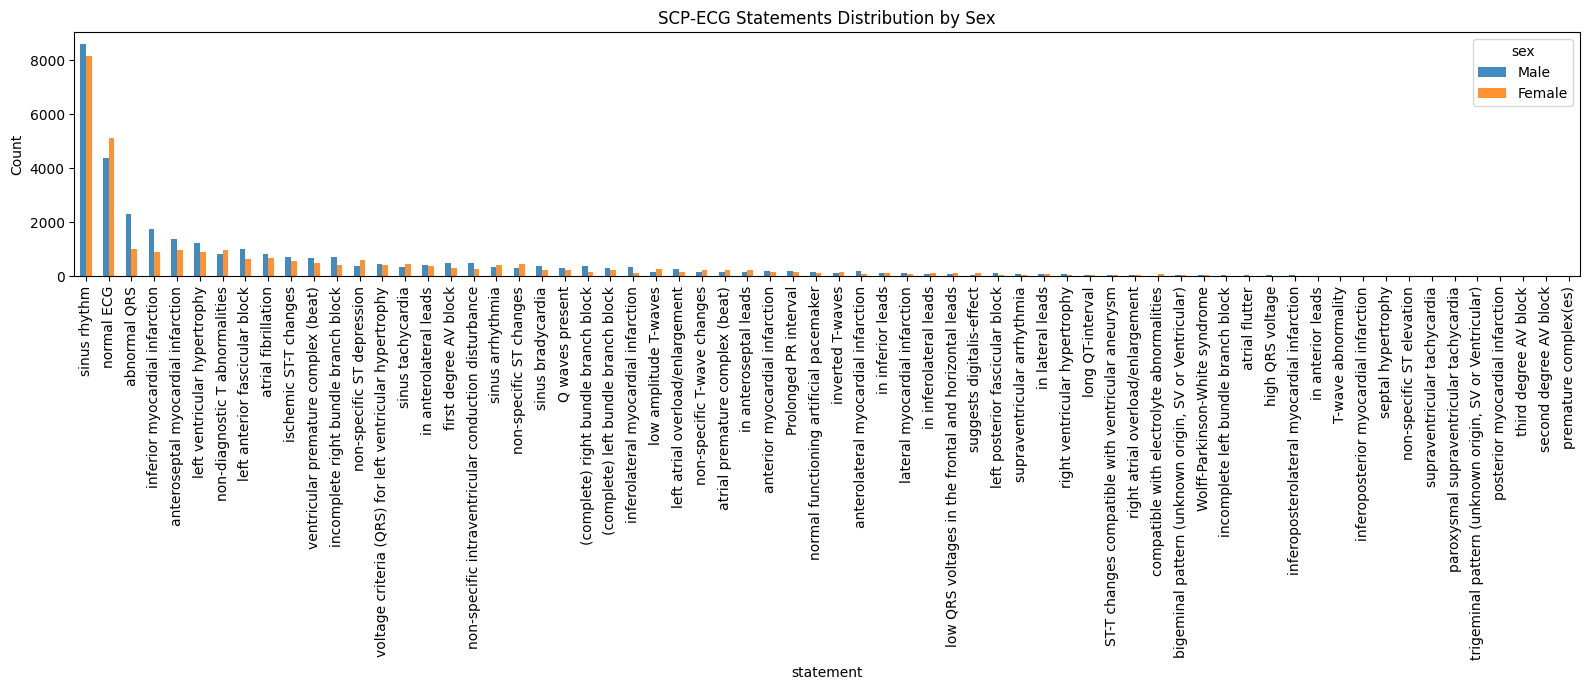

In [21]:
# 5. SCP-ECG statements

# Use the full mapping table, not the diagnostic-filtered one
df["scp_statements"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, scp_all, "SCP-ECG Statement Description")
)

all_labels = [str(label) for sublist in df["scp_statements"] for label in sublist]
label_counts = Counter(all_labels)

print("\nSCP-ECG Statement distribution (all shown):")
for k, v in label_counts.items():
    print(k, ":", v)

plt.figure(figsize=(14,7))

# Sort by frequency for readability
sorted_counts = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

plt.bar(sorted_counts.keys(), sorted_counts.values(), color="pink")
plt.xticks(rotation=90)
plt.title("SCP-ECG Statements Distribution")
plt.xlabel("Statement")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Pie chart of top categories
top_n = 10
top_items = dict(label_counts.most_common(top_n))

plt.figure(figsize=(8,8))
plt.pie(top_items.values(), labels=top_items.keys(), autopct="%1.1f%%")
plt.title(f"Top {top_n} SCP‑ECG Statements (Pie Chart)")
plt.tight_layout()
plt.show()



# 5-a SCP‑ECG Statements separated by sex

# Build long table: one row per (sex, scp_statement)
rows = []
for idx, row in df.iterrows():
    sex = row["sex"]
    for label in row["scp_statements"]:
        rows.append({"sex": sex, "statement": str(label)})

scp_sex_df = pd.DataFrame(rows)

# Count per sex per statement
scp_sex_counts = (
    scp_sex_df.groupby(["statement", "sex"])
              .size()
              .unstack(fill_value=0)
)

scp_sex_counts = scp_sex_counts[["Male", "Female"]]

# Sort by total count
scp_sex_counts = scp_sex_counts.loc[
    scp_sex_counts.sum(axis=1).sort_values(ascending=False).index
]

# Plot grouped bar chart
plt.figure(figsize=(16,7))
scp_sex_counts.plot(kind="bar", figsize=(16,7), alpha=0.85)
plt.xticks(rotation=90)
plt.title("SCP‑ECG Statements Distribution by Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In the case of SCP-ECG statements distribution, "sinus rhythm" dominates with 39% and is followed by "normal ECG" which takes 22.1%. On the other hand, the data is distributed pretty equal based on the sex.

### 2.5. 12‑lead ECG example

Sampling frequency: 100
Signal shape (samples × leads): (1000, 12)
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


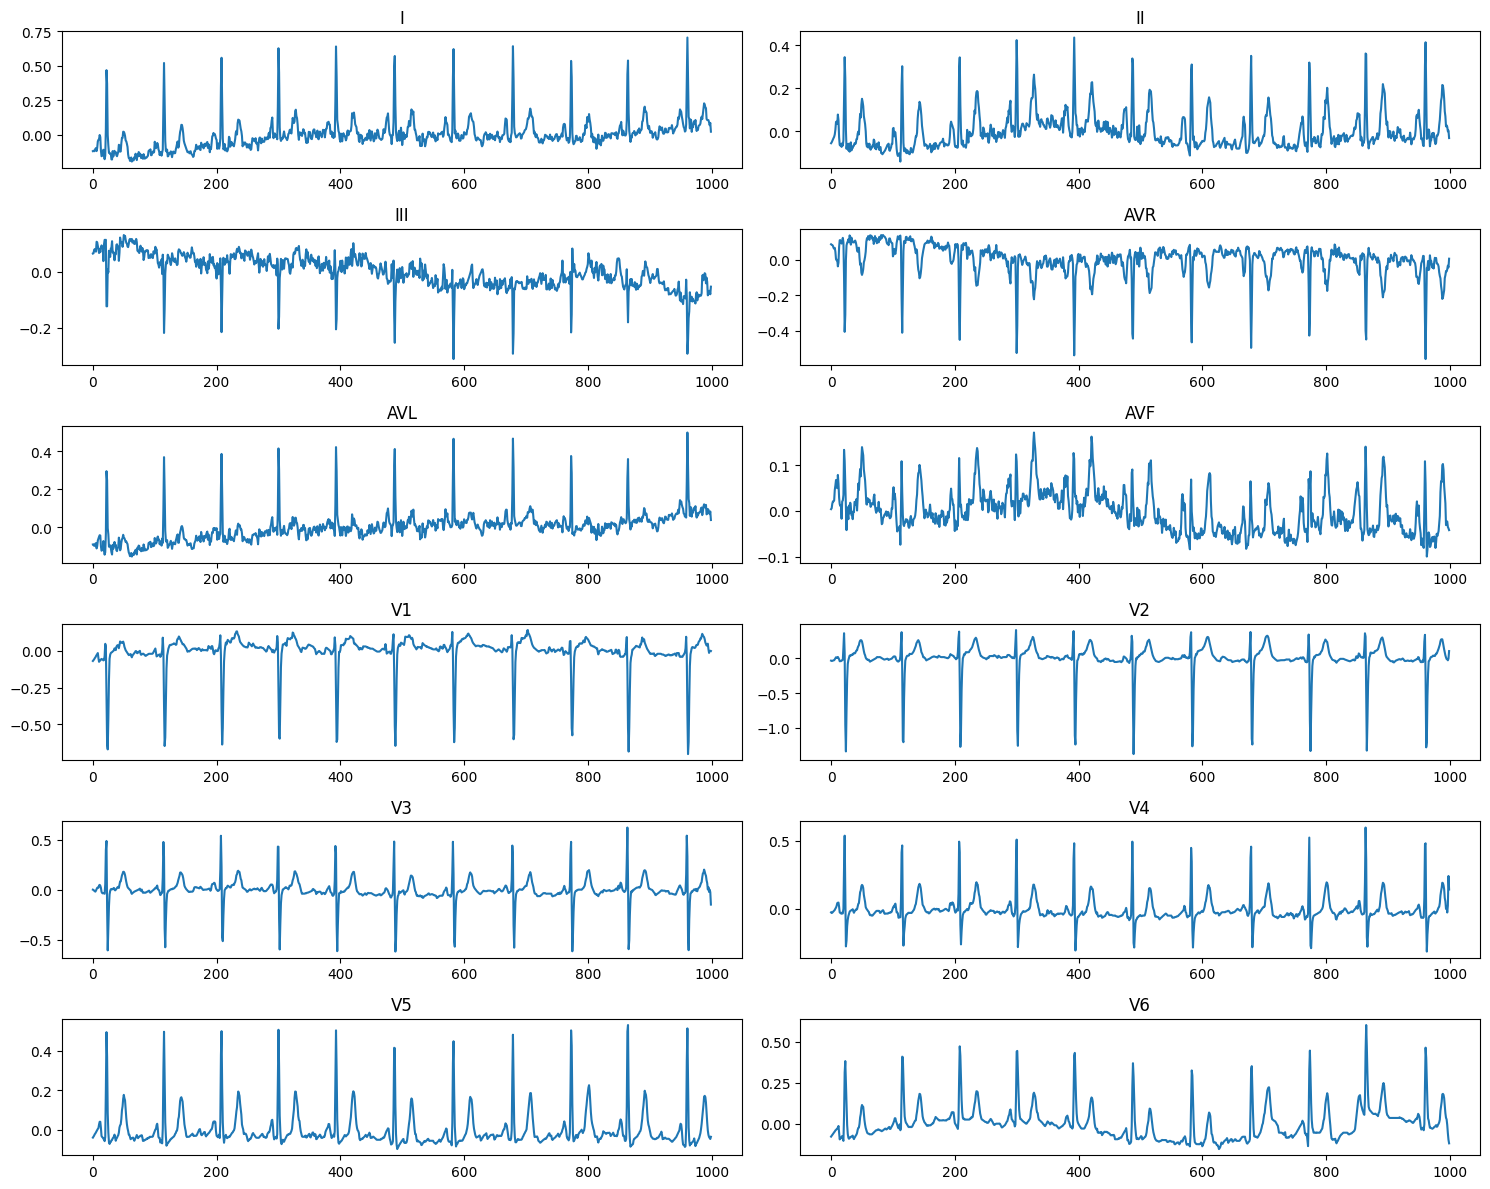

In [22]:
# Load metadata
df = pd.read_csv(path + "ptbxl_database.csv", index_col="ecg_id")
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

# Pick one ECG example
example_id = 1
record_path = path + df.loc[example_id].filename_lr  # low‑resolution (100 Hz)

# Load the 12‑lead ECG
signal, meta = wfdb.rdsamp(record_path)

print("Sampling frequency:", meta['fs'])
print("Signal shape (samples × leads):", signal.shape)
print("Lead names:", meta['sig_name'])

# Plot all 12 leads
plt.figure(figsize=(15, 12))
for i in range(12):
    plt.subplot(6, 2, i+1)
    plt.plot(signal[:, i])
    plt.title(meta['sig_name'][i])
    plt.tight_layout()

plt.show()
